# 🎵 Prueba del Modelo de Clasificación de Audio

Este notebook carga el modelo entrenado y hace predicciones en audios de una carpeta.

In [5]:
# 📦 Importaciones
import os
import sys
import glob
from pathlib import Path
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import librosa
import librosa.display
from IPython.display import Audio, display
from src.utils.config import *
print("✅ Importaciones completadas")

✅ Importaciones completadas


## 1️⃣ Cargar el modelo entrenado

In [6]:
# 🔧 CONFIGURACIÓN - IGUAL A PREPROCESS.PY

# Ruta del modelo entrenado
MODEL_PATH = FINAL_MODEL_DIR / "best_mfcc_cnn.pt"
# MODEL_PATH = CHECKPOINT_DIR / "checkpoint_epoch_12.pt"

# Ruta del label mapping
LABEL_MAPPING_PATH = LABEL_MAPPING["human_label"]

# Carpeta con audios para probar
AUDIO_FOLDER = TEST_AUDIO_FOLDER

# Configuración de audio - MISMO QUE EN PREPROCESS.PY
SAMPLE_RATE = 22050
N_MELS = 128
HOP_LENGTH = 512
N_FFT = 2048
TARGET_DURATION = 5.0  # segundos (IMPORTANTE: igual a preprocess)
N_MFCC = 40  # igual a preprocess
PEAK_TARGET = 0.99  # igual a preprocess

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"🚀 Device: {DEVICE}")
print(f"📂 Carpeta de audios: {AUDIO_FOLDER}")
print(f"💾 Modelo: {MODEL_PATH}")
print(f"🏷️ Label mapping: {LABEL_MAPPING_PATH}")
print(f"\n🎵 Configuración de Audio (IDENTICA A PREPROCESS.PY):")
print(f"   - Sample Rate: {SAMPLE_RATE}")
print(f"   - N Mels: {N_MELS}")
print(f"   - N FFT: {N_FFT}")
print(f"   - Hop Length: {HOP_LENGTH}")
print(f"   - N MFCC: {N_MFCC}")
print(f"   - Target Duration: {TARGET_DURATION}s")
print(f"   - Peak Target: {PEAK_TARGET}")

🚀 Device: cuda
📂 Carpeta de audios: /home/andres/Documentos/proyecto4geeks/tests/audios
💾 Modelo: /home/andres/Documentos/proyecto4geeks/models/final/best_mfcc_cnn.pt
🏷️ Label mapping: /home/andres/Documentos/proyecto4geeks/data/interim/processed_dataset/label_mapping_human_label.pkl

🎵 Configuración de Audio (IDENTICA A PREPROCESS.PY):
   - Sample Rate: 22050
   - N Mels: 128
   - N FFT: 2048
   - Hop Length: 512
   - N MFCC: 40
   - Target Duration: 5.0s
   - Peak Target: 0.99


In [7]:
# 📥 Cargar label mapping
with open(LABEL_MAPPING_PATH, 'rb') as f:
    label_mapping = pickle.load(f)

# Extraer label2idx e idx2label
if isinstance(label_mapping, dict) and 'label2idx' in label_mapping:
    label2idx = label_mapping['label2idx']
    idx2label = label_mapping.get('idx2label', {int(v): k for k, v in label2idx.items()})
else:
    label2idx = label_mapping
    idx2label = {int(v): k for k, v in label2idx.items()}

num_classes = len(label2idx)

print(f"✅ Label mapping cargado: {num_classes} clases")
print(f"\n📋 Primeras 10 clases:")
for i, (label, idx) in enumerate(list(label2idx.items())[:10]):
    print(f"   {idx}: {label}")

✅ Label mapping cargado: 23 clases

📋 Primeras 10 clases:
   0: alert_sirem
   1: ambient_noise
   2: another_animal
   3: breathing
   4: car_crash
   5: construction_noise
   6: crime
   7: crying
   8: dog
   9: domestic_activity


In [8]:
# 🧠 Cargar el modelo
from src.models.hybrid_cnn import ImprovedMFCCCNN

model = ImprovedMFCCCNN(num_classes=num_classes, dropout=0.25).to(DEVICE)
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)

# model.load_state_dict(checkpoint["model_state"])
# model.eval()
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

total_params = sum(p.numel() for p in model.parameters())
print(f"✅ Modelo cargado")
print(f"   - Parámetros: {total_params:,}")
print(f"   - Clases: {num_classes}")

✅ Modelo cargado
   - Parámetros: 1,180,375
   - Clases: 23


## 2️⃣ Procesar y predecir audios

In [9]:
# 🔊 IMPORTAR TORCHAUDIO Y DEPENDENCIAS
import soundfile as sf
import torchaudio.transforms as T
import torch.nn.functional as F

# ✅ FUNCIONES DE PROCESAMIENTO - LINEA POR LINEA IGUAL A PREPROCESS.PY

def ensure_mono(waveform):
    """
    Convierte a mono - IDENTICO A PREPROCESS.PY lineas 351-356
    Si es 1D -> unsqueeze
    Si tiene más de 1 canal -> promediar canales (IMPORTANTE para estéreo/multicanal)
    """
    if waveform.ndim == 1:
        waveform = waveform.unsqueeze(0)
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)  # Promediar canales
    return waveform

def fix_length(waveform, target_duration, sr):
    """
    Fija longitud - IDENTICO A PREPROCESS.PY lineas 364-373
    Si target_duration es None, no hace nada
    Si es mayor, trunca
    Si es menor, padea con ceros
    """
    if target_duration is None:
        return waveform
    target_len = int(sr * float(target_duration))
    current = waveform.shape[-1]
    if current > target_len:
        return waveform[..., :target_len]
    if current < target_len:
        return F.pad(waveform, (0, target_len - current))  # Pad ceros al final
    return waveform

def normalize_peak(waveform, peak_target=0.99):
    """
    Normaliza pico - IDENTICO A PREPROCESS.PY lineas 358-362
    IMPORTANTE: clamp_min(1e-8) evita división por cero
    """
    peak = waveform.abs().max().clamp_min(1e-8)  # Evita NaN
    return waveform / peak * float(peak_target)

def cargar_audio_con_transformaciones(audio_path, sr=SAMPLE_RATE, target_duration=TARGET_DURATION):
    """
    Carga un audio EXACTAMENTE IGUAL a preprocess.py process_single_audio()
    
    ✅ BITRATE: soundfile decodifica a PCM, independiente del bitrate original
    ✅ CANALES: ensure_mono() convierte a mono igual que preprocess.py
    
    Pipeline:
    1. soundfile.read() - decodifica audio
    2. tensor conversion
    3. ensure_mono() - manejo igual de canales
    4. Resample si sr diferente
    5. fix_length() - truncar/padear
    6. normalize_peak() - con clamp_min
    7. MelSpectrogram
    8. AmplitudeToDB
    9. MFCC
    """
    try:
        # 1️⃣ CARGAR AUDIO - soundfile.read() igual a preprocess.py
        audio_np, sr_loaded = sf.read(str(audio_path))
        # En este punto:
        # - Si era MP3/OGG/etc -> decodificado a PCM
        # - Bitrate original no importa (ya está en sample values)
        # - Canales: audio_np.shape es (samples,) para mono o (samples, channels) para estéreo
        
        # 2️⃣ CONVERTIR A TENSOR
        waveform = torch.tensor(audio_np, dtype=torch.float32)
        
        # 3️⃣ ASEGURAR MONO - IDENTICO A PREPROCESS.PY
        waveform = ensure_mono(waveform)
        
        # 4️⃣ RESAMPLE SI SR DIFERENTE
        if sr_loaded != sr:
            resampler = T.Resample(sr_loaded, sr)
            waveform = resampler(waveform)
        
        waveform = waveform.to(DEVICE)
        
        # 5️⃣ FIJAR LONGITUD - IDENTICO A PREPROCESS.PY
        waveform = fix_length(waveform, target_duration, sr)
        
        # 6️⃣ NORMALIZACIÓN DE PICO - IDENTICO A PREPROCESS.PY
        waveform = normalize_peak(waveform, peak_target=PEAK_TARGET)
        
        # 7️⃣ CREAR TRANSFORMADORES - IDENTICOS A PREPROCESS.PY lineas 102-120
        mel_transform = T.MelSpectrogram(
            sample_rate=sr,
            n_fft=N_FFT,
            hop_length=HOP_LENGTH,
            n_mels=N_MELS,
            power=2.0
        ).to(DEVICE)
        
        amplitude_to_db = T.AmplitudeToDB(stype='power').to(DEVICE)
        
        mfcc_transform = T.MFCC(
            sample_rate=sr,
            n_mfcc=N_MFCC,
            melkwargs={
                'n_fft': N_FFT,
                'hop_length': HOP_LENGTH,
                'n_mels': N_MELS,
                'center': True,
                'power': 2.0,
            }
        ).to(DEVICE)
        
        # 8️⃣ APLICAR TRANSFORMACIONES
        with torch.inference_mode():
            mel = mel_transform(waveform)
            mel_db = amplitude_to_db(mel)
            mfcc = mfcc_transform(waveform)
        
        return mel_db, mfcc, mel
    
    except Exception as e:
        print(f"❌ Error procesando {audio_path}: {e}")
        import traceback
        traceback.print_exc()
        return None, None, None

print("✅ Funciones de procesamiento cargadas")
print("✅ IDENTICAS a preprocess.py (bitrate y canales manejados igual)")

✅ Funciones de procesamiento cargadas
✅ IDENTICAS a preprocess.py (bitrate y canales manejados igual)


In [10]:
def predecir_audio(model, audio_path, device=DEVICE):
    """
    Predicción en audio - USANDO TRANSFORMACIONES DE PREPROCESS.PY
    """
    # Cargar y procesar audio
    mel_db, mfcc, raw_mel = cargar_audio_con_transformaciones(audio_path)
    
    if mel_db is None:
        return None
    
    # Normalizar mel para el tamaño esperado del modelo
    # El modelo espera: [batch, channels, mel_bins, frames]
    mel_db = mel_db.squeeze(0)  # Remover batch dimension si existe
    
    # Calcular target frames basado en el mel_db obtenido
    frames = mel_db.shape[-1]
    target_frames = 360  # frames esperados por el modelo
    
    if frames > target_frames:
        mel_db = mel_db[:, :target_frames]
    elif frames < target_frames:
        pad = target_frames - frames
        mel_db = F.pad(mel_db, (0, pad), 'constant', 0)
    
    # Preparar para el modelo: [1, 1, 128, 360]
    mel_tensor = mel_db.unsqueeze(0).unsqueeze(0).to(device)  
    
    # Predicción
    with torch.no_grad():
        logits = model(mel_tensor)
        probs = torch.softmax(logits, dim=1)
        confidence, predicted_idx = torch.max(probs, 1)
    
    predicted_idx = predicted_idx.item()
    confidence = confidence.item()
    predicted_label = idx2label.get(predicted_idx, "DESCONOCIDO")
    
    # Top 5 predicciones
    top5_probs, top5_indices = torch.topk(probs[0], k=min(5, len(probs[0])))
    top5 = [(idx2label.get(idx.item(), "DESCONOCIDO"), prob.item()) 
            for idx, prob in zip(top5_indices, top5_probs)]
    
    return {
        'predicted_label': predicted_label,
        'predicted_idx': predicted_idx,
        'confidence': confidence,
        'top5': top5,
        'mel_db': mel_db.cpu().numpy(),
        'audio_path': audio_path
    }

print("✅ Función de predicción cargada")

✅ Función de predicción cargada


In [11]:
# 🔍 Buscar audios en la carpeta
audio_extensions = ['*.mp3', '*.wav', '*.flac', '*.ogg', '*.m4a']
audio_files = []

for ext in audio_extensions:
    audio_files.extend(glob.glob(str(AUDIO_FOLDER / ext)))
    audio_files.extend(glob.glob(str(AUDIO_FOLDER / ext.upper())))

audio_files = list(set(audio_files))  # Eliminar duplicados

print(f"📂 Encontrados {len(audio_files)} audios en {AUDIO_FOLDER}")

if len(audio_files) == 0:
    print(f"\n⚠️ No se encontraron audios. Crea la carpeta y añade archivos:")
    print(f"   mkdir -p {AUDIO_FOLDER}")
    print(f"   cp /ruta/a/tus/audios/* {AUDIO_FOLDER}/")
else:
    print(f"\n📋 Primeros 5 audios:")
    for i, audio_file in enumerate(audio_files[:5]):
        print(f"   {i+1}. {Path(audio_file).name}")

📂 Encontrados 5 audios en /home/andres/Documentos/proyecto4geeks/tests/audios

📋 Primeros 5 audios:
   1. freesound_community-dog-barking-70772.mp3
   2. 11325622-police-siren-sound-effect-240674.mp3
   3. m4a1_unsil-1_d6515.mp3
   4. audio_607a0.mp3
   5. dragon-studio-dog-barking-406629.mp3


In [12]:
# 🎯 Hacer predicciones en todos los audios
results = []

print(f"\n🔮 Haciendo predicciones...\n")

for i, audio_file in enumerate(audio_files):
    print(f"[{i+1}/{len(audio_files)}] {Path(audio_file).name}...", end=" ", flush=True)
    
    result = predecir_audio(model, audio_file)
    
    if result:
        results.append(result)
        confidence_pct = result['confidence'] * 100
        print(f"✅ {result['predicted_label']} ({confidence_pct:.1f}%)")
    else:
        print(f"❌ Error")

print(f"\n✅ Predicciones completadas: {len(results)}/{len(audio_files)}")


🔮 Haciendo predicciones...

[1/5] freesound_community-dog-barking-70772.mp3... ✅ another_animal (31.0%)
[2/5] 11325622-police-siren-sound-effect-240674.mp3... ✅ another_animal (37.6%)
[3/5] m4a1_unsil-1_d6515.mp3... ✅ explosion (49.6%)
[4/5] audio_607a0.mp3... ✅ gun_shot (44.2%)
[5/5] dragon-studio-dog-barking-406629.mp3... ✅ another_animal (37.6%)

✅ Predicciones completadas: 5/5


## 3️⃣ Mostrar resultados

In [13]:
# 📊 Tabla de resultados
df_results = pd.DataFrame([
    {
        'Archivo': Path(r['audio_path']).name,
        'Predicción': r['predicted_label'],
        'Confianza': f"{r['confidence']*100:.2f}%",
        'Confianza (valor)': r['confidence']
    }
    for r in results
])

# Ordenar por confianza descendente
df_results = df_results.sort_values('Confianza (valor)', ascending=False)

print("\n" + "="*80)
print("📊 RESULTADOS DE PREDICCIONES")
print("="*80)
print(df_results[['Archivo', 'Predicción', 'Confianza']].to_string(index=False))
print("="*80)


📊 RESULTADOS DE PREDICCIONES
                                      Archivo     Predicción Confianza
                       m4a1_unsil-1_d6515.mp3      explosion    49.58%
                              audio_607a0.mp3       gun_shot    44.23%
11325622-police-siren-sound-effect-240674.mp3 another_animal    37.65%
         dragon-studio-dog-barking-406629.mp3 another_animal    37.65%
    freesound_community-dog-barking-70772.mp3 another_animal    31.00%


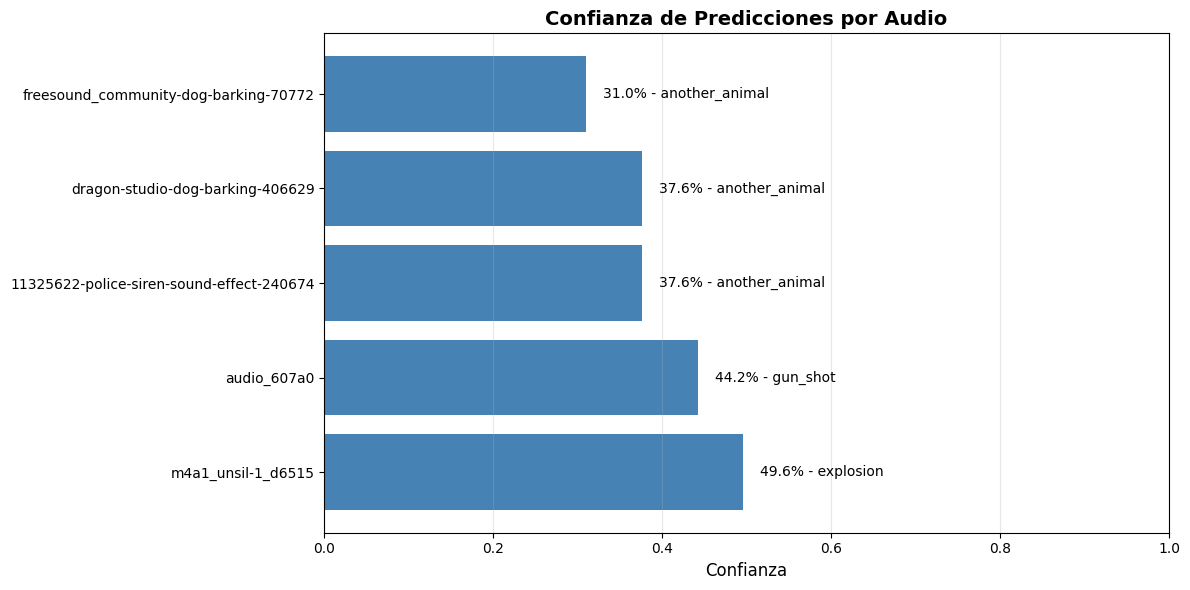

In [14]:
# 📈 Gráfico de confianzas
plt.figure(figsize=(12, 6))
plt.barh(range(len(df_results)), df_results['Confianza (valor)'].values, color='steelblue')
plt.yticks(range(len(df_results)), [Path(p).stem for p in df_results['Archivo'].values])
plt.xlabel('Confianza', fontsize=12)
plt.title('Confianza de Predicciones por Audio', fontsize=14, fontweight='bold')
plt.xlim([0, 1])
plt.grid(axis='x', alpha=0.3)

# Añadir valores en las barras
for i, (conf, audio) in enumerate(zip(df_results['Confianza (valor)'].values, 
                                        df_results['Predicción'].values)):
    plt.text(conf + 0.02, i, f"{conf*100:.1f}% - {audio}", 
            va='center', fontsize=10)

plt.tight_layout()
plt.show()

## 4️⃣ Detalles por audio

In [15]:
# 🔍 Mostrar detalles de cada audio con el mel-spectrogram
for idx, result in enumerate(results):
    print(f"\n{'='*80}")
    print(f"📁 Audio {idx+1}: {Path(result['audio_path']).name}")
    print(f"{'='*80}")
    
    # Información principal
    print(f"\n🎯 PREDICCIÓN PRINCIPAL:")
    print(f"   Clase: {result['predicted_label']}")
    print(f"   Confianza: {result['confidence']*100:.2f}%")
    
    # Top 5
    print(f"\n🏆 TOP 5 PREDICCIONES:")
    for rank, (label, prob) in enumerate(result['top5'], 1):
        print(f"   {rank}. {label:30s} - {prob*100:5.2f}%")
    
    # Visualizar mel-spectrogram
    # fig, ax = plt.subplots(figsize=(12, 4))
    # mel_spec = result['mel_spec']
    # img = librosa.display.specshow(mel_spec, sr=SAMPLE_RATE, hop_length=HOP_LENGTH, 
    #                                 x_axis='time', y_axis='mel', ax=ax, cmap='magma')
    # ax.set_title(f"Mel-Spectrogram: {result['predicted_label']} ({result['confidence']*100:.1f}%)", 
    #             fontsize=12, fontweight='bold')
    # fig.colorbar(img, ax=ax, format='%+2.0f dB')
    # plt.tight_layout()
    # plt.show()
    
    # Reproducir audio
    print(f"\n🔊 Audio:")
    display(Audio(result['audio_path']))


📁 Audio 1: freesound_community-dog-barking-70772.mp3

🎯 PREDICCIÓN PRINCIPAL:
   Clase: another_animal
   Confianza: 31.00%

🏆 TOP 5 PREDICCIONES:
   1. another_animal                 - 31.00%
   2. weather                        - 11.39%
   3. traffic                        - 10.23%
   4. glass_metal                    -  7.32%
   5. voice                          -  6.21%

🔊 Audio:



📁 Audio 2: 11325622-police-siren-sound-effect-240674.mp3

🎯 PREDICCIÓN PRINCIPAL:
   Clase: another_animal
   Confianza: 37.65%

🏆 TOP 5 PREDICCIONES:
   1. another_animal                 - 37.65%
   2. traffic                        - 11.14%
   3. weather                        -  9.76%
   4. doors                          -  6.69%
   5. glass_metal                    -  6.69%

🔊 Audio:



📁 Audio 3: m4a1_unsil-1_d6515.mp3

🎯 PREDICCIÓN PRINCIPAL:
   Clase: explosion
   Confianza: 49.58%

🏆 TOP 5 PREDICCIONES:
   1. explosion                      - 49.58%
   2. gun_shot                       - 44.39%
   3. glass_metal                    -  1.45%
   4. fire                           -  1.22%
   5. water                          -  0.39%

🔊 Audio:



📁 Audio 4: audio_607a0.mp3

🎯 PREDICCIÓN PRINCIPAL:
   Clase: gun_shot
   Confianza: 44.23%

🏆 TOP 5 PREDICCIONES:
   1. gun_shot                       - 44.23%
   2. explosion                      - 43.59%
   3. glass_metal                    -  1.64%
   4. weather                        -  1.42%
   5. water                          -  1.29%

🔊 Audio:



📁 Audio 5: dragon-studio-dog-barking-406629.mp3

🎯 PREDICCIÓN PRINCIPAL:
   Clase: another_animal
   Confianza: 37.65%

🏆 TOP 5 PREDICCIONES:
   1. another_animal                 - 37.65%
   2. traffic                        - 11.14%
   3. weather                        -  9.76%
   4. doors                          -  6.69%
   5. glass_metal                    -  6.69%

🔊 Audio:


## 5️⃣ Estadísticas generales

In [16]:
# 📊 Estadísticas
confidences = df_results['Confianza (valor)'].values

print(f"\n{'='*80}")
print("📊 ESTADÍSTICAS GENERALES")
print(f"{'='*80}")
print(f"Total de audios: {len(results)}")
print(f"Confianza promedio: {np.mean(confidences)*100:.2f}%")
print(f"Confianza máxima: {np.max(confidences)*100:.2f}%")
print(f"Confianza mínima: {np.min(confidences)*100:.2f}%")
print(f"Desviación estándar: {np.std(confidences)*100:.2f}%")

# Clases predichas
print(f"\n🏷️ CLASES PREDICHAS:")
class_counts = df_results['Predicción'].value_counts()
for label, count in class_counts.items():
    percentage = (count / len(results)) * 100
    print(f"   {label:30s} - {count} ({percentage:.1f}%)")

print(f"{'='*80}")


📊 ESTADÍSTICAS GENERALES
Total de audios: 5
Confianza promedio: 40.02%
Confianza máxima: 49.58%
Confianza mínima: 31.00%
Desviación estándar: 6.35%

🏷️ CLASES PREDICHAS:
   another_animal                 - 3 (60.0%)
   explosion                      - 1 (20.0%)
   gun_shot                       - 1 (20.0%)


In [17]:
# 📥 Exportar resultados a CSV (opcional)
csv_path = AUDIO_FOLDER / "predicciones.csv"
df_results[['Archivo', 'Predicción', 'Confianza']].to_csv(csv_path, index=False)
print(f"\n✅ Resultados exportados a: {csv_path}")


✅ Resultados exportados a: /home/andres/Documentos/proyecto4geeks/tests/audios/predicciones.csv
